# 09. Dataset Profiling with AI

Dataset profiling is the bridge between a business dataset and a credible causal design. In ordinary analytics, profiling often means checking column types, missing values, outliers, and duplicates. In causal inference, those checks are only the surface. We also need to ask:

- What is the unit of analysis?
- When is treatment assigned?
- Which variables were measured before treatment?
- Which variables might be outcomes, mediators, descendants of treatment, or leakage?
- Does missingness depend on treatment, outcome, or operational workflow?
- What domain questions must be answered before any estimator is trusted?

This notebook teaches a workflow where deterministic Python profiling does the reliable measurement work, and local LLMs help generate structured review notes, domain questions, and potential failure modes. The LLM is useful, but it is never treated as the source of truth.

## Learning Goals

By the end of this notebook you should be able to:

1. Profile a dataset in a way that is specific to causal inference, not just general data quality.
2. Separate variable availability from variable eligibility for adjustment.
3. Detect common dataset risks: duplicate units, timing ambiguity, post-treatment controls, missingness patterns, and leakage.
4. Build a compact evidence bundle that an LLM can review without seeing the whole dataset.
5. Parse, audit, and score AI-generated dataset-profile notes.
6. Compare multiple local models on the same profiling task and treat instability as an empirical result.

## Live Model Note

This course treats LLM behavior as an empirical object. These notebooks may include live local-model calls, so outputs can vary across model versions, hardware, decoding settings, prompt wording, package versions, and reruns. That instability is part of the lesson: AI-assisted causal work needs deterministic checks, structured outputs, model comparison, repair logic, and human review.

For this notebook in particular, dataset profiling can be brittle because the model has to infer roles from incomplete metadata. A model may correctly identify missingness but miss timing leakage, or it may notice post-treatment variables but overstate whether a causal effect is identifiable. We will let that brittleness remain visible and then audit it.

## 1. Setup

The deterministic parts of the notebook use `pandas`, `numpy`, `scikit-learn`, `statsmodels`, and visualization packages. The optional AI sections use the shared local Hugging Face utilities used throughout Course 05.

The notebook is safe to render as HTML because the live model calls are controlled by flags. If you render without executing live model cells, the notebook still documents the workflow. If you run the notebook locally with the downloaded models, it becomes a model-comparison lab.

In [1]:
import importlib.util
import json
import sys
import textwrap
import warnings
from pathlib import Path
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
import torch
from IPython.display import Markdown, display
from pydantic import BaseModel, Field

warnings.filterwarnings('ignore', category=FutureWarning)

In [2]:
RUN_LIVE_LOCAL_LLM = True
RUN_FULL_MODEL_COMPARISON = True
RUN_SCHEMA_REPAIR_RETRY = True

LOCAL_SMOKE_TEST_MODEL = 'Qwen/Qwen2.5-0.5B-Instruct'
LOCAL_FAST_MODEL = 'Qwen/Qwen2.5-7B-Instruct'
LOCAL_STRONG_MODEL = 'Qwen/Qwen2.5-14B-Instruct'
LOCAL_SCALE_MODEL = 'Qwen/Qwen2.5-32B-Instruct'

LOCAL_ALT_REASONING_MODEL = 'microsoft/Phi-3.5-mini-instruct'
LOCAL_ALT_OPEN_MODEL = 'mistralai/Mistral-7B-Instruct-v0.3'
LOCAL_MISTRAL_SMALL_MODEL = 'mistralai/Mistral-Small-3.1-24B-Instruct-2503'
LOCAL_GEMMA_MODEL = 'google/gemma-3-27b-it'
LOCAL_LLAMA_MODEL = 'meta-llama/Meta-Llama-3.1-8B-Instruct'

MODEL_ID = LOCAL_FAST_MODEL
MAX_NEW_TOKENS = 1800
TEMPERATURE = 0.0
SEED = 209
MODEL_COMPARISON_CASE_LIMIT = 1

MODELS_TO_COMPARE = [
    ('Qwen 0.5B', LOCAL_SMOKE_TEST_MODEL, 'pipeline smoke test'),
    ('Qwen 7B', LOCAL_FAST_MODEL, 'fast default'),
    ('Qwen 14B', LOCAL_STRONG_MODEL, 'strong local analysis'),
    ('Qwen 32B', LOCAL_SCALE_MODEL, 'scale comparison'),
    ('Phi mini', LOCAL_ALT_REASONING_MODEL, 'compact non-Qwen comparison'),
    ('Mistral 7B', LOCAL_ALT_OPEN_MODEL, '7B model-family comparison'),
    ('Mistral Small 24B', LOCAL_MISTRAL_SMALL_MODEL, 'strong non-Qwen comparison'),
    ('Gemma 3 27B', LOCAL_GEMMA_MODEL, 'large non-Qwen comparison'),
    ('Llama 3.1 8B', LOCAL_LLAMA_MODEL, 'industry-standard instruct baseline'),
]

np.random.seed(SEED)
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_colwidth', 140)

In [3]:
def has_package(module_name):
    return importlib.util.find_spec(module_name) is not None

package_status = pd.DataFrame(
    [
        {'package': 'pandas', 'available': has_package('pandas'), 'used_for': 'deterministic profiling tables'},
        {'package': 'seaborn', 'available': has_package('seaborn'), 'used_for': 'profiling plots'},
        {'package': 'statsmodels', 'available': has_package('statsmodels'), 'used_for': 'simple regression smoke tests'},
        {'package': 'pydantic', 'available': has_package('pydantic'), 'used_for': 'structured AI profile schema'},
        {'package': 'transformers', 'available': has_package('transformers'), 'used_for': 'optional local LLM profiling'},
        {'package': 'torch', 'available': has_package('torch'), 'used_for': 'GPU inference if live LLMs are enabled'},
    ]
)

print(f'CUDA available to this kernel: {torch.cuda.is_available()}')
package_status

CUDA available to this kernel: True


,package,available,used_for
0,pandas,True,deterministic profiling tables
1,seaborn,True,profiling plots
2,statsmodels,True,simple regression smoke tests
3,pydantic,True,structured AI profile schema
4,transformers,True,optional local LLM profiling
5,torch,True,GPU inference if live LLMs are enabled


## 2. Why Dataset Profiling Is Causal Work

A causal analysis can fail before the estimator is chosen. Many failures come from the dataset itself:

- The row is not the unit at which treatment is assigned.
- The outcome window overlaps with the treatment window.
- A variable that looks like a covariate is actually measured after treatment.
- Duplicates create implicit weights for some units.
- Missingness reveals operational workflow, not random noise.
- A feature contains future information and quietly leaks the outcome.

A useful AI assistant can help produce a sharper checklist, but it must be grounded in deterministic evidence: schema summaries, timing metadata, missingness tables, duplicate checks, and simple balance diagnostics.

In [4]:
profiling_layers = pd.DataFrame(
    [
        {
            'layer': 'Basic data quality',
            'question': 'Do rows, columns, types, missingness, and duplicates look coherent?',
            'causal consequence': 'Prevents accidental weighting, impossible joins, and broken estimands.',
        },
        {
            'layer': 'Unit and time',
            'question': 'What is one observational unit, and when is treatment assigned?',
            'causal consequence': 'Defines the estimand, exposure window, outcome window, and clustering level.',
        },
        {
            'layer': 'Variable role',
            'question': 'Was each variable measured before treatment, during treatment, or after treatment?',
            'causal consequence': 'Separates eligible confounders from mediators, outcomes, and leakage.',
        },
        {
            'layer': 'Assignment audit',
            'question': 'Which pre-treatment variables predict treatment?',
            'causal consequence': 'Reveals confounding, positivity risks, and targeting rules.',
        },
        {
            'layer': 'Outcome and guardrails',
            'question': 'Are outcomes defined after treatment and consistently measured?',
            'causal consequence': 'Protects against metric drift and partial outcome capture.',
        },
        {
            'layer': 'AI-assisted review',
            'question': 'What risks and domain questions does a model infer from the evidence bundle?',
            'causal consequence': 'Expands the review, but only after deterministic profiling has created evidence.',
        },
    ]
)
profiling_layers

,layer,question,causal consequence
0,Basic data quality,"Do rows, columns, types, missingness, and duplicates look coherent?","Prevents accidental weighting, impossible joins, and broken estimands."
1,Unit and time,"What is one observational unit, and when is treatment assigned?","Defines the estimand, exposure window, outcome window, and clustering level."
2,Variable role,"Was each variable measured before treatment, during treatment, or after treatment?","Separates eligible confounders from mediators, outcomes, and leakage."
3,Assignment audit,Which pre-treatment variables predict treatment?,"Reveals confounding, positivity risks, and targeting rules."
4,Outcome and guardrails,Are outcomes defined after treatment and consistently measured?,Protects against metric drift and partial outcome capture.
5,AI-assisted review,What risks and domain questions does a model infer from the evidence bundle?,"Expands the review, but only after deterministic profiling has created evidence."


### Discussion

The important distinction is **availability versus admissibility**. A column may be available in the table but inadmissible in an adjustment set. For example, `agent_uses_ai` may be highly predictive of workload after an assistant is enabled, but it is downstream of enablement. Adjusting for it would change the estimand from the total effect of enablement to something closer to a controlled direct effect.

This is why a causal profile needs timing metadata. Without timing, an AI assistant may treat every predictive column as a useful control. That is exactly the behavior we want to catch.

## 3. Running Example: AI Support Assistant Rollout

We will use a synthetic dataset for a company that rolled out an AI assistant to support teams. The business wants to know whether enablement reduced human-handled workload without harming customer experience.

The row grain is intended to be `team_id` by `week_start`. The treatment is `assistant_enabled`. The primary outcome is `human_handled_hours`. The guardrail outcome is `customer_satisfaction_score`.

The dataset intentionally contains realistic profiling issues:

- Some duplicated team-weeks.
- Missing baseline volume that depends on region and readiness.
- Missing satisfaction scores that are more common in high-volume queues.
- Post-treatment variables that are tempting but should not be adjusted for when estimating a total effect.
- A future variable that leaks information from the next week.

In [5]:
def simulate_support_assistant_data(n_teams=90, n_weeks=14, seed=SEED):
    rng = np.random.default_rng(seed)
    teams = pd.DataFrame(
        {
            'team_id': [f'T{idx:03d}' for idx in range(n_teams)],
            'region': rng.choice(['Americas', 'EMEA', 'APAC'], size=n_teams, p=[0.45, 0.35, 0.20]),
            'queue_type': rng.choice(['billing', 'technical', 'retention'], size=n_teams, p=[0.35, 0.45, 0.20]),
            'team_readiness': rng.normal(0, 1, size=n_teams),
            'manager_priority': rng.binomial(1, 0.35, size=n_teams),
        }
    )
    teams['baseline_ticket_volume'] = (
        240
        + 45 * (teams['queue_type'] == 'technical').astype(int)
        + 35 * (teams['queue_type'] == 'retention').astype(int)
        + 18 * teams['manager_priority']
        + 22 * teams['team_readiness']
        + rng.normal(0, 30, size=n_teams)
    ).clip(80, None)
    teams['baseline_satisfaction'] = (
        82
        - 0.018 * teams['baseline_ticket_volume']
        + 2.2 * teams['team_readiness']
        + rng.normal(0, 2.5, size=n_teams)
    ).clip(55, 95)

    weeks = pd.date_range('2025-01-06', periods=n_weeks, freq='W-MON')
    rows = []
    for _, team in teams.iterrows():
        rollout_score = (
            -0.7
            + 0.95 * team['manager_priority']
            + 0.65 * team['team_readiness']
            + 0.0035 * team['baseline_ticket_volume']
            + (0.25 if team['region'] == 'Americas' else 0.0)
        )
        rollout_probability = 1 / (1 + np.exp(-rollout_score))
        eligible_week = rng.integers(4, 10) if rng.uniform() < rollout_probability else 99
        for week_idx, week_start in enumerate(weeks):
            enabled = int(week_idx >= eligible_week)
            seasonal_pressure = 18 * np.sin((week_idx + 1) / n_weeks * 2 * np.pi)
            backlog_start = (
                55
                + 0.18 * team['baseline_ticket_volume']
                - 7.5 * team['team_readiness']
                + 9 * (team['queue_type'] == 'retention')
                + seasonal_pressure
                + rng.normal(0, 12)
            )
            staffing_hours = (
                420
                + 0.32 * team['baseline_ticket_volume']
                - 0.45 * backlog_start
                + 18 * team['manager_priority']
                + rng.normal(0, 18)
            )
            agent_uses_ai = np.nan
            deflection_rate = np.nan
            if enabled:
                agent_uses_ai = float(np.clip(
                    0.35
                    + 0.16 * team['team_readiness']
                    + 0.06 * team['manager_priority']
                    + rng.normal(0, 0.07),
                    0.05,
                    0.92,
                ))
                deflection_rate = float(np.clip(
                    0.12
                    + 0.38 * agent_uses_ai
                    + rng.normal(0, 0.04),
                    0.02,
                    0.65,
                ))

            true_total_effect = -22 - 12 * max(team['team_readiness'], 0)
            human_handled_hours = (
                120
                + 0.42 * team['baseline_ticket_volume']
                + 0.65 * backlog_start
                - 0.18 * staffing_hours
                - 7 * team['team_readiness']
                + true_total_effect * enabled
                + rng.normal(0, 18)
            )
            customer_satisfaction_score = float(np.clip(
                team['baseline_satisfaction']
                - 0.018 * backlog_start
                + 1.4 * enabled
                - 2.8 * max(enabled * (deflection_rate if not np.isnan(deflection_rate) else 0) - 0.35, 0)
                + rng.normal(0, 2.4),
                35,
                98,
            ))
            next_week_backlog = backlog_start + 0.09 * human_handled_hours - 7 * enabled + rng.normal(0, 10)

            rows.append(
                {
                    'team_id': team['team_id'],
                    'week_start': week_start,
                    'region': team['region'],
                    'queue_type': team['queue_type'],
                    'assistant_enabled': enabled,
                    'baseline_ticket_volume': team['baseline_ticket_volume'],
                    'baseline_satisfaction': team['baseline_satisfaction'],
                    'team_readiness': team['team_readiness'],
                    'manager_priority': team['manager_priority'],
                    'backlog_start': backlog_start,
                    'staffing_hours': staffing_hours,
                    'agent_uses_ai': agent_uses_ai,
                    'deflection_rate': deflection_rate,
                    'human_handled_hours': human_handled_hours,
                    'customer_satisfaction_score': customer_satisfaction_score,
                    'next_week_backlog': next_week_backlog,
                }
            )
    df = pd.DataFrame(rows)

    readiness_missing = (df['region'].eq('APAC') & (df['team_readiness'] < -0.25) & (rng.uniform(size=len(df)) < 0.28))
    df.loc[readiness_missing, 'baseline_ticket_volume'] = np.nan

    csat_missing = ((df['queue_type'].eq('technical')) & (df['backlog_start'] > df['backlog_start'].quantile(0.70)) & (rng.uniform(size=len(df)) < 0.32))
    df.loc[csat_missing, 'customer_satisfaction_score'] = np.nan

    duplicate_indices = rng.choice(df.index, size=8, replace=False)
    duplicates = df.loc[duplicate_indices].copy()
    duplicates['staffing_hours'] = duplicates['staffing_hours'] + rng.normal(0, 5, size=len(duplicates))
    df = pd.concat([df, duplicates], ignore_index=True).sample(frac=1, random_state=seed).reset_index(drop=True)
    return df

raw = simulate_support_assistant_data()
raw.head()

,team_id,week_start,region,queue_type,assistant_enabled,baseline_ticket_volume,baseline_satisfaction,team_readiness,manager_priority,backlog_start,staffing_hours,agent_uses_ai,deflection_rate,human_handled_hours,customer_satisfaction_score,next_week_backlog
0,T049,2025-03-03,Americas,technical,1,318.680028,80.363466,1.144821,1,84.914952,499.181159,0.570938,0.400712,161.649237,79.808041,79.694226
1,T069,2025-02-03,Americas,retention,0,330.834274,76.563602,1.978773,0,142.913594,481.671278,NaN,NaN,237.072721,75.507517,175.875164
2,T052,2025-03-31,Americas,technical,1,255.578769,69.362715,-0.029563,1,123.375787,477.236520,0.462384,0.234673,185.545918,66.100149,123.649601
3,T048,2025-01-06,Americas,billing,0,304.385110,72.127583,-0.500037,0,142.275779,426.880542,NaN,NaN,272.949791,68.228324,165.666386
4,T022,2025-02-24,Americas,technical,1,317.634111,76.879693,0.494718,0,102.309229,438.123429,0.367080,0.180488,233.986433,79.314878,108.473944


In [6]:
data_dictionary = pd.DataFrame(
    [
        {'variable': 'team_id', 'description': 'Support team identifier.', 'timing': 'unit id', 'initial_role': 'unit identifier'},
        {'variable': 'week_start', 'description': 'Start date for the reporting week.', 'timing': 'time id', 'initial_role': 'time identifier'},
        {'variable': 'region', 'description': 'Operating region for the team.', 'timing': 'pre-treatment', 'initial_role': 'candidate confounder'},
        {'variable': 'queue_type', 'description': 'Primary queue served by the team.', 'timing': 'pre-treatment', 'initial_role': 'candidate confounder'},
        {'variable': 'assistant_enabled', 'description': 'Whether the AI assistant was enabled for the team during the week.', 'timing': 'treatment week', 'initial_role': 'treatment'},
        {'variable': 'baseline_ticket_volume', 'description': 'Average weekly ticket volume before rollout planning.', 'timing': 'pre-treatment', 'initial_role': 'candidate confounder'},
        {'variable': 'baseline_satisfaction', 'description': 'Pre-rollout customer satisfaction score.', 'timing': 'pre-treatment', 'initial_role': 'candidate confounder'},
        {'variable': 'team_readiness', 'description': 'Internal readiness score used by enablement managers.', 'timing': 'pre-treatment', 'initial_role': 'candidate confounder'},
        {'variable': 'manager_priority', 'description': 'Indicator that leadership prioritized the team for early enablement.', 'timing': 'pre-treatment', 'initial_role': 'candidate confounder'},
        {'variable': 'backlog_start', 'description': 'Open ticket backlog at the beginning of the week.', 'timing': 'pre-treatment within week', 'initial_role': 'candidate confounder'},
        {'variable': 'staffing_hours', 'description': 'Planned human staffing capacity for the week.', 'timing': 'pre-treatment within week', 'initial_role': 'candidate confounder'},
        {'variable': 'agent_uses_ai', 'description': 'Share of agents actively using the assistant after enablement.', 'timing': 'post-treatment', 'initial_role': 'mediator or compliance measure'},
        {'variable': 'deflection_rate', 'description': 'Share of contacts deflected after assistant interactions.', 'timing': 'post-treatment', 'initial_role': 'mediator'},
        {'variable': 'human_handled_hours', 'description': 'Human workload hours during the week.', 'timing': 'outcome window', 'initial_role': 'primary outcome'},
        {'variable': 'customer_satisfaction_score', 'description': 'Customer satisfaction score for tickets resolved during the week.', 'timing': 'outcome window', 'initial_role': 'guardrail outcome'},
        {'variable': 'next_week_backlog', 'description': 'Open backlog measured at the beginning of the following week.', 'timing': 'future', 'initial_role': 'future leakage risk'},
    ]
)

data_dictionary

,variable,description,timing,initial_role
0,team_id,Support team identifier.,unit id,unit identifier
1,week_start,Start date for the reporting week.,time id,time identifier
2,region,Operating region for the team.,pre-treatment,candidate confounder
3,queue_type,Primary queue served by the team.,pre-treatment,candidate confounder
4,assistant_enabled,Whether the AI assistant was enabled for the team during the week.,treatment week,treatment
5,baseline_ticket_volume,Average weekly ticket volume before rollout planning.,pre-treatment,candidate confounder
6,baseline_satisfaction,Pre-rollout customer satisfaction score.,pre-treatment,candidate confounder
7,team_readiness,Internal readiness score used by enablement managers.,pre-treatment,candidate confounder
8,manager_priority,Indicator that leadership prioritized the team for early enablement.,pre-treatment,candidate confounder
9,backlog_start,Open ticket backlog at the beginning of the week.,pre-treatment within week,candidate confounder


### Discussion

The data dictionary is doing causal work. The column name `deflection_rate` sounds like a useful operational control. The timing metadata says it is post-treatment. That changes how we treat it.

For the total effect of enablement, post-treatment usage and deflection are part of the pathway by which enablement may affect workload. Adjusting for them would remove part of the effect we are trying to estimate. They may be useful in mechanism analysis, but not in the main total-effect adjustment set.

## 4. Basic Grain and Schema Profile

The first deterministic task is to verify the intended row grain. Here the intended unit is one row per `team_id` and `week_start`. If that grain is violated, every downstream estimate silently changes because duplicated rows give extra weight to some team-weeks.

In [7]:
def basic_schema_profile(df, unit_cols):
    duplicate_count = df.duplicated(unit_cols, keep=False).sum()
    expected_unique_units = df[unit_cols].drop_duplicates().shape[0]
    return pd.DataFrame(
        [
            {'metric': 'rows', 'value': len(df)},
            {'metric': 'columns', 'value': df.shape[1]},
            {'metric': 'unique team-weeks', 'value': expected_unique_units},
            {'metric': 'duplicated rows by intended grain', 'value': int(duplicate_count)},
            {'metric': 'first week', 'value': df['week_start'].min()},
            {'metric': 'last week', 'value': df['week_start'].max()},
            {'metric': 'treated rows', 'value': int(df['assistant_enabled'].sum())},
            {'metric': 'untreated rows', 'value': int((1 - df['assistant_enabled']).sum())},
        ]
    )

schema_profile = basic_schema_profile(raw, ['team_id', 'week_start'])
schema_profile

,metric,value
0,rows,1268
1,columns,16
2,unique team-weeks,1260
3,duplicated rows by intended grain,16
4,first week,2025-01-06 00:00:00
5,last week,2025-04-07 00:00:00
6,treated rows,463
7,untreated rows,805


In [8]:
type_profile = pd.DataFrame(
    {
        'variable': raw.columns,
        'dtype': [str(raw[col].dtype) for col in raw.columns],
        'non_null': [raw[col].notna().sum() for col in raw.columns],
        'missing_share': [raw[col].isna().mean() for col in raw.columns],
        'unique_values': [raw[col].nunique(dropna=True) for col in raw.columns],
    }
).merge(data_dictionary[['variable', 'timing', 'initial_role']], on='variable', how='left')

type_profile.sort_values(['missing_share', 'unique_values'], ascending=[False, True])

,variable,dtype,non_null,missing_share,unique_values,timing,initial_role
11,agent_uses_ai,float64,463,0.634858,451,post-treatment,mediator or compliance measure
12,deflection_rate,float64,463,0.634858,458,post-treatment,mediator
14,customer_satisfaction_score,float64,1216,0.041009,1208,outcome window,guardrail outcome
5,baseline_ticket_volume,float64,1244,0.018927,90,pre-treatment,candidate confounder
4,assistant_enabled,int64,1268,0.000000,2,treatment week,treatment
8,manager_priority,int64,1268,0.000000,2,pre-treatment,candidate confounder
2,region,str,1268,0.000000,3,pre-treatment,candidate confounder
3,queue_type,str,1268,0.000000,3,pre-treatment,candidate confounder
1,week_start,datetime64[us],1268,0.000000,14,time id,time identifier
0,team_id,str,1268,0.000000,90,unit id,unit identifier


### Discussion

General profiling would stop at missingness and types. Causal profiling attaches those symptoms to timing and role.

For example, missing values in `agent_uses_ai` and `deflection_rate` are expected for untreated rows because those variables are only meaningful after enablement. That is different from missing pre-treatment ticket volume or missing guardrail outcomes. The former is structural; the latter can threaten identification or outcome validity.

## 5. Missingness as a Causal Signal

Missingness is not just a data-cleaning nuisance. It can reveal operational workflow. If satisfaction is missing more often in high-backlog treated weeks, complete-case analysis may select a non-comparable subset. If a pre-treatment covariate is missing more often in one rollout region, adjustment may rely on a biased analytic sample.

In [9]:
missing_table = (
    raw.isna()
    .mean()
    .rename('missing_share')
    .reset_index()
    .rename(columns={'index': 'variable'})
    .merge(data_dictionary[['variable', 'timing', 'initial_role']], on='variable', how='left')
    .sort_values('missing_share', ascending=False)
)

missing_by_treatment = (
    raw.assign(treatment_group=np.where(raw['assistant_enabled'].eq(1), 'enabled', 'not enabled'))
    .groupby('treatment_group')
    .apply(lambda frame: frame.isna().mean(numeric_only=False), include_groups=False)
    .T.reset_index()
    .rename(columns={'index': 'variable'})
)

missing_table.head(10)

,variable,missing_share,timing,initial_role
12,deflection_rate,0.634858,post-treatment,mediator
11,agent_uses_ai,0.634858,post-treatment,mediator or compliance measure
14,customer_satisfaction_score,0.041009,outcome window,guardrail outcome
5,baseline_ticket_volume,0.018927,pre-treatment,candidate confounder
3,queue_type,0.000000,pre-treatment,candidate confounder
0,team_id,0.000000,unit id,unit identifier
2,region,0.000000,pre-treatment,candidate confounder
1,week_start,0.000000,time id,time identifier
7,team_readiness,0.000000,pre-treatment,candidate confounder
6,baseline_satisfaction,0.000000,pre-treatment,candidate confounder


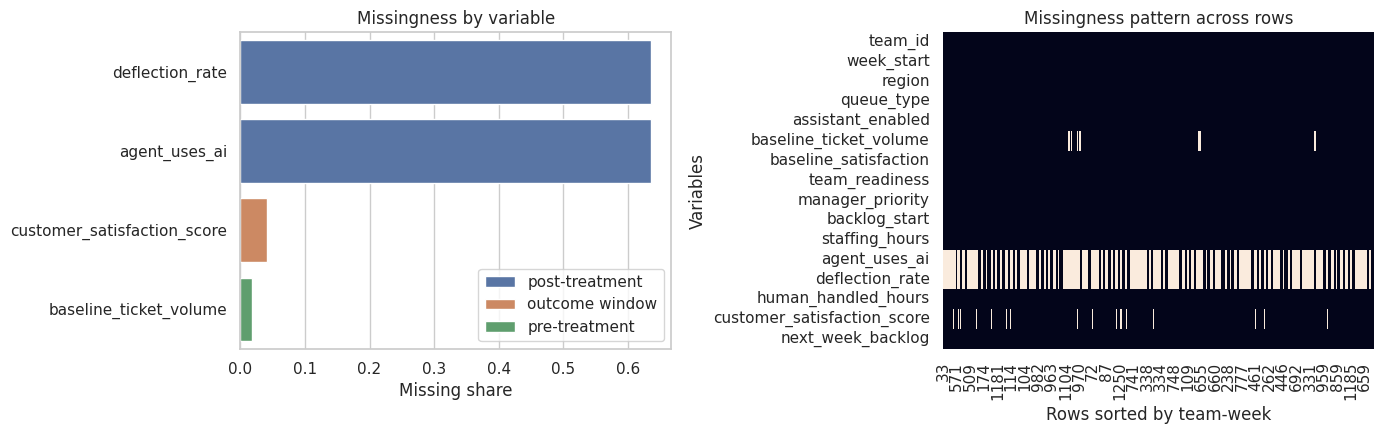

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_missing = missing_table.query('missing_share > 0').copy()
sns.barplot(data=plot_missing, y='variable', x='missing_share', hue='timing', dodge=False, ax=axes[0])
axes[0].set_title('Missingness by variable')
axes[0].set_xlabel('Missing share')
axes[0].set_ylabel('')
axes[0].legend(loc='lower right')

missing_heatmap_data = raw.sort_values(['team_id', 'week_start']).isna().astype(int)
sns.heatmap(missing_heatmap_data.T, cbar=False, ax=axes[1])
axes[1].set_title('Missingness pattern across rows')
axes[1].set_xlabel('Rows sorted by team-week')
axes[1].set_ylabel('Variables')
plt.tight_layout()
plt.show()

In [11]:
missing_contrast = missing_by_treatment.merge(data_dictionary[['variable', 'timing', 'initial_role']], on='variable', how='left')
if {'enabled', 'not enabled'}.issubset(missing_contrast.columns):
    missing_contrast['enabled_minus_not_enabled'] = missing_contrast['enabled'] - missing_contrast['not enabled']
else:
    missing_contrast['enabled_minus_not_enabled'] = np.nan
missing_contrast.sort_values('enabled_minus_not_enabled', key=lambda s: s.abs(), ascending=False).head(10)

,variable,enabled,not enabled,timing,initial_role,enabled_minus_not_enabled
12,deflection_rate,0.000000,1.000000,post-treatment,mediator,-1.000000
11,agent_uses_ai,0.000000,1.000000,post-treatment,mediator or compliance measure,-1.000000
14,customer_satisfaction_score,0.008639,0.059627,outcome window,guardrail outcome,-0.050988
5,baseline_ticket_volume,0.010799,0.023602,pre-treatment,candidate confounder,-0.012803
3,queue_type,0.000000,0.000000,pre-treatment,candidate confounder,0.000000
0,team_id,0.000000,0.000000,unit id,unit identifier,0.000000
2,region,0.000000,0.000000,pre-treatment,candidate confounder,0.000000
1,week_start,0.000000,0.000000,time id,time identifier,0.000000
7,team_readiness,0.000000,0.000000,pre-treatment,candidate confounder,0.000000
6,baseline_satisfaction,0.000000,0.000000,pre-treatment,candidate confounder,0.000000


### Discussion

This table should make us uncomfortable in two different ways.

First, post-treatment variables are missing mainly in untreated rows. That is expected and should not be imputed as if the values were accidentally lost. Second, some variables that matter for analysis, such as baseline volume or satisfaction, can be missing because of workflow. That kind of missingness should become a design question: Who is absent from the analytic sample, and is that absence related to treatment assignment or outcomes?

## 6. Duplicate and Unit-Integrity Checks

Duplicates are especially dangerous in panel causal analysis. A duplicated treated team-week can make the treated group look larger. A duplicated high-backlog week can also overweight a particular operational condition.

The goal is not only to count duplicates. We want to inspect whether duplicate rows disagree on fields that should be fixed for the same unit-time.

In [12]:
unit_cols = ['team_id', 'week_start']
duplicate_rows = raw.loc[raw.duplicated(unit_cols, keep=False)].sort_values(unit_cols)

duplicate_summary = (
    duplicate_rows
    .groupby(unit_cols)
    .agg(
        duplicate_rows=('team_id', 'size'),
        staffing_min=('staffing_hours', 'min'),
        staffing_max=('staffing_hours', 'max'),
        workload_min=('human_handled_hours', 'min'),
        workload_max=('human_handled_hours', 'max'),
    )
    .reset_index()
)
duplicate_summary['staffing_range'] = duplicate_summary['staffing_max'] - duplicate_summary['staffing_min']
duplicate_summary['workload_range'] = duplicate_summary['workload_max'] - duplicate_summary['workload_min']
duplicate_summary.head(10)

,team_id,week_start,duplicate_rows,staffing_min,staffing_max,workload_min,workload_max,staffing_range,workload_range
0,T011,2025-03-03,2,493.282383,496.713121,187.039698,187.039698,3.430739,0.0
1,T015,2025-02-24,2,508.097029,508.453978,184.279689,184.279689,0.356949,0.0
2,T034,2025-01-06,2,470.258640,481.926088,202.833084,202.833084,11.667448,0.0
3,T064,2025-02-03,2,452.553596,461.421005,187.053952,187.053952,8.867410,0.0
4,T064,2025-03-03,2,502.056521,507.144791,149.135410,149.135410,5.088270,0.0
5,T071,2025-02-17,2,466.979210,468.267164,153.671606,153.671606,1.287954,0.0
6,T079,2025-01-13,2,463.032303,475.142666,266.199179,266.199179,12.110362,0.0
7,T085,2025-03-03,2,462.597699,467.323954,231.153278,231.153278,4.726255,0.0


### Discussion

When duplicates disagree, we need to determine whether they are true duplicate extracts, multiple records that need aggregation, or conflicting source-system records. The causal question cannot answer this for us. A data owner must resolve the unit definition.

## 7. Treatment Assignment and Pre-Treatment Balance

Before estimating anything, we ask whether treatment assignment is associated with pre-treatment variables. In an experiment, randomized assignment should make large systematic differences less likely. In an observational rollout, assignment often follows readiness, queue pressure, manager priority, or customer risk.

A simple standardized mean difference table is not a full identification argument, but it is a fast profiling tool.

In [13]:
PRE_TREATMENT_NUMERIC = [
    'baseline_ticket_volume',
    'baseline_satisfaction',
    'team_readiness',
    'manager_priority',
    'backlog_start',
    'staffing_hours',
]


def standardized_mean_difference(df, treatment_col, variables):
    rows = []
    treated = df[df[treatment_col].eq(1)]
    control = df[df[treatment_col].eq(0)]
    for variable in variables:
        t = treated[variable].dropna()
        c = control[variable].dropna()
        pooled_sd = np.sqrt((t.var(ddof=1) + c.var(ddof=1)) / 2)
        smd = np.nan if pooled_sd == 0 or np.isnan(pooled_sd) else (t.mean() - c.mean()) / pooled_sd
        rows.append(
            {
                'variable': variable,
                'treated_mean': t.mean(),
                'control_mean': c.mean(),
                'smd': smd,
                'abs_smd': abs(smd) if not np.isnan(smd) else np.nan,
            }
        )
    return pd.DataFrame(rows).sort_values('abs_smd', ascending=False)

balance_table = standardized_mean_difference(raw, 'assistant_enabled', PRE_TREATMENT_NUMERIC)
balance_table

,variable,treated_mean,control_mean,smd,abs_smd
4,backlog_start,98.232173,114.079097,-0.898040,0.898040
5,staffing_hours,479.813009,467.306275,0.517624,0.517624
2,team_readiness,0.253501,-0.033788,0.284007,0.284007
0,baseline_ticket_volume,289.011570,279.646479,0.250091,0.250091
3,manager_priority,0.598272,0.479503,0.239765,0.239765
1,baseline_satisfaction,77.066097,76.330197,0.234774,0.234774


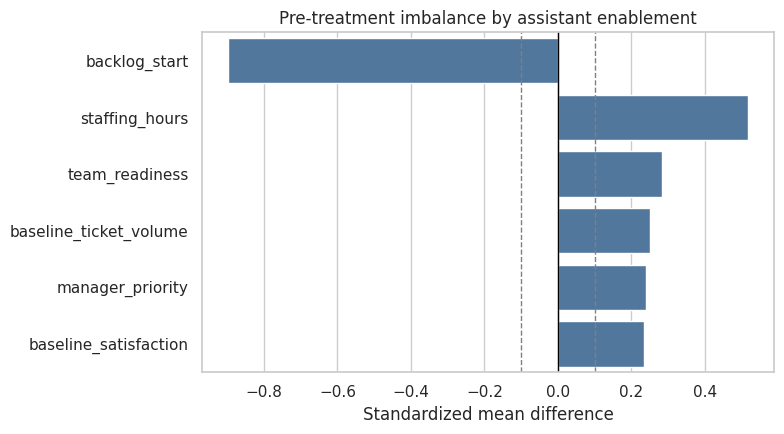

In [14]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=balance_table, y='variable', x='smd', color='#4477AA', ax=ax)
ax.axvline(0, color='black', linewidth=1)
ax.axvline(0.10, color='gray', linestyle='--', linewidth=1)
ax.axvline(-0.10, color='gray', linestyle='--', linewidth=1)
ax.set_title('Pre-treatment imbalance by assistant enablement')
ax.set_xlabel('Standardized mean difference')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

### Discussion

The treated rows differ from untreated rows on variables measured before treatment. That does not prove confounding by itself, but it strongly suggests that a raw treated-versus-untreated contrast is not a credible causal estimate.

The AI assistant should be able to notice this pattern if we give it the balance table. It should not infer that adjustment solves everything. It should ask whether these variables are sufficient, whether treatment timing is correctly represented, and whether team-level clustering or staggered rollout matters.

## 8. Timing, Mediators, and Leakage Scan

A profiler for causal inference must explicitly name variables that should not be adjusted for in the primary total-effect model.

Here are three different reasons a variable can be risky:

- **Mediator:** affected by treatment and part of the mechanism.
- **Outcome or guardrail:** measured after treatment and should not be used as a control.
- **Future leakage:** measured after the outcome window or using future information.

These roles are design-dependent. The same variable can be valid in one estimand and invalid in another.

In [15]:
role_scan = data_dictionary.copy()
role_scan['adjustment_eligibility_for_total_effect'] = np.select(
    [
        role_scan['timing'].isin(['pre-treatment', 'pre-treatment within week']),
        role_scan['initial_role'].eq('treatment'),
        role_scan['timing'].isin(['post-treatment', 'outcome window', 'future']),
    ],
    [
        'eligible candidate, subject to causal graph review',
        'not a control: treatment',
        'exclude from primary adjustment set',
    ],
    default='not an adjustment variable',
)
role_scan[['variable', 'timing', 'initial_role', 'adjustment_eligibility_for_total_effect']]

,variable,timing,initial_role,adjustment_eligibility_for_total_effect
0,team_id,unit id,unit identifier,not an adjustment variable
1,week_start,time id,time identifier,not an adjustment variable
2,region,pre-treatment,candidate confounder,"eligible candidate, subject to causal graph review"
3,queue_type,pre-treatment,candidate confounder,"eligible candidate, subject to causal graph review"
4,assistant_enabled,treatment week,treatment,not a control: treatment
5,baseline_ticket_volume,pre-treatment,candidate confounder,"eligible candidate, subject to causal graph review"
6,baseline_satisfaction,pre-treatment,candidate confounder,"eligible candidate, subject to causal graph review"
7,team_readiness,pre-treatment,candidate confounder,"eligible candidate, subject to causal graph review"
8,manager_priority,pre-treatment,candidate confounder,"eligible candidate, subject to causal graph review"
9,backlog_start,pre-treatment within week,candidate confounder,"eligible candidate, subject to causal graph review"


In [16]:
numeric_cols = raw.select_dtypes(include='number').columns.tolist()
leakage_correlations = (
    raw[numeric_cols]
    .corr(numeric_only=True)['human_handled_hours']
    .drop('human_handled_hours')
    .abs()
    .sort_values(ascending=False)
    .rename('abs_corr_with_workload')
    .reset_index()
    .rename(columns={'index': 'variable'})
    .merge(data_dictionary[['variable', 'timing', 'initial_role']], on='variable', how='left')
)
leakage_correlations.head(10)

,variable,abs_corr_with_workload,timing,initial_role
0,next_week_backlog,0.732711,future,future leakage risk
1,backlog_start,0.697131,pre-treatment within week,candidate confounder
2,assistant_enabled,0.557883,treatment week,treatment
3,agent_uses_ai,0.331058,post-treatment,mediator or compliance measure
4,baseline_ticket_volume,0.275312,pre-treatment,candidate confounder
5,deflection_rate,0.272418,post-treatment,mediator
6,customer_satisfaction_score,0.257702,outcome window,guardrail outcome
7,team_readiness,0.201766,pre-treatment,candidate confounder
8,staffing_hours,0.191644,pre-treatment within week,candidate confounder
9,baseline_satisfaction,0.127335,pre-treatment,candidate confounder


### Discussion

High predictive value is not the same as valid adjustment. `next_week_backlog` can be predictive because it contains future information. `deflection_rate` can be predictive because it lies on a treatment pathway. These variables are exactly the kind of columns that automated ML feature selection would like and a causal analyst should question.

This is where AI assistance can help as a reviewer: ask the model to classify variable roles and explain its uncertainty. But the deterministic timing table remains the anchor.

## 9. Regression Smoke Test: How Profiling Changes the Story

This section is not meant to estimate the final causal effect. It is a smoke test that shows how sensitive the treatment coefficient is to variable choice.

We compare three models:

1. A naive treated-versus-untreated regression.
2. A pre-treatment adjustment model.
3. A bad adjustment model that includes post-treatment and future variables.

The third model is intentionally wrong for the total effect. It is included because it reveals a common failure mode: the model may look more predictive while answering a different causal question.

In [17]:
analysis_df = raw.dropna(subset=['human_handled_hours', 'baseline_ticket_volume', 'baseline_satisfaction']).copy()

models = {
    'naive': 'human_handled_hours ~ assistant_enabled',
    'pre-treatment adjustment': (
        'human_handled_hours ~ assistant_enabled + baseline_ticket_volume + baseline_satisfaction + '
        'team_readiness + manager_priority + backlog_start + staffing_hours + C(region) + C(queue_type)'
    ),
    'bad post-treatment/leaky adjustment': (
        'human_handled_hours ~ assistant_enabled + baseline_ticket_volume + baseline_satisfaction + '
        'team_readiness + manager_priority + backlog_start + staffing_hours + C(region) + C(queue_type) + '
        'agent_uses_ai + deflection_rate + next_week_backlog'
    ),
}

coef_rows = []
for label, formula in models.items():
    model_df = analysis_df.copy()
    if 'agent_uses_ai' in formula:
        model_df = model_df.dropna(subset=['agent_uses_ai', 'deflection_rate', 'next_week_backlog'])
    fitted = smf.ols(formula, data=model_df).fit(cov_type='HC3')
    coef_rows.append(
        {
            'model': label,
            'rows_used': int(fitted.nobs),
            'assistant_enabled_coef': fitted.params.get('assistant_enabled', np.nan),
            'robust_se': fitted.bse.get('assistant_enabled', np.nan),
            'p_value': fitted.pvalues.get('assistant_enabled', np.nan),
            'r_squared': fitted.rsquared,
        }
    )

coef_table = pd.DataFrame(coef_rows)
coef_table

,model,rows_used,assistant_enabled_coef,robust_se,p_value,r_squared
0,naive,1244,-39.516817,1.680661,3.026786e-122,0.314412
1,pre-treatment adjustment,1244,-28.385061,1.257982,9.792889e-113,0.687568
2,bad post-treatment/leaky adjustment,458,13.191847,16.934753,4.359911e-01,0.576314


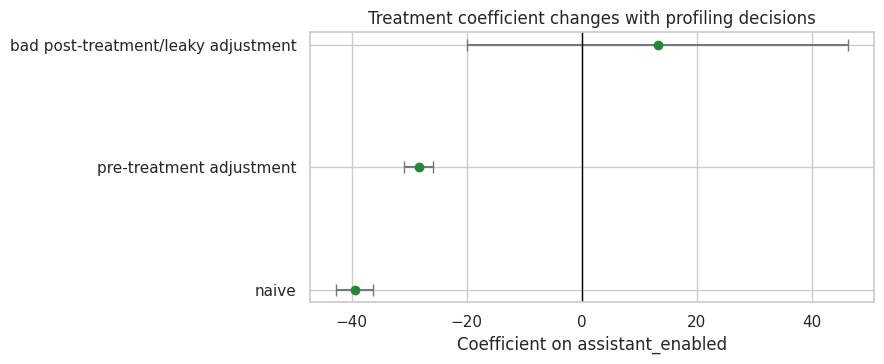

In [18]:
fig, ax = plt.subplots(figsize=(9, 3.8))
plot_coef = coef_table.assign(
    lower=lambda d: d['assistant_enabled_coef'] - 1.96 * d['robust_se'],
    upper=lambda d: d['assistant_enabled_coef'] + 1.96 * d['robust_se'],
)
ax.errorbar(
    plot_coef['assistant_enabled_coef'],
    plot_coef['model'],
    xerr=[plot_coef['assistant_enabled_coef'] - plot_coef['lower'], plot_coef['upper'] - plot_coef['assistant_enabled_coef']],
    fmt='o',
    color='#228833',
    ecolor='#777777',
    capsize=4,
)
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Treatment coefficient changes with profiling decisions')
ax.set_xlabel('Coefficient on assistant_enabled')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

### Discussion

The bad adjustment model may use fewer rows because post-treatment variables only exist after enablement. That sample restriction alone changes the estimand. It also adjusts for variables affected by treatment, which blocks part of the treatment pathway.

The correct lesson is not that the pre-treatment model is automatically valid. The lesson is that profiling reveals which model specifications are not even candidates for the main total-effect analysis.

## 10. Build an Evidence Bundle for AI Review

An LLM should not receive the full raw dataset as a substitute for profiling. Instead, give it a compact evidence bundle created by deterministic code.

A good bundle includes:

- Business question and intended estimand.
- Row grain and unit checks.
- Data dictionary with timing metadata.
- Missingness summaries.
- Balance diagnostics.
- Duplicate examples.
- Timing and leakage candidates.
- A warning that the LLM should not claim identification from profiling alone.

In [19]:
def dataframe_records(df, max_rows=20):
    return json.loads(df.head(max_rows).to_json(orient='records', date_format='iso'))

profile_bundle = {
    'business_question': 'Did enabling the AI support assistant reduce human-handled workload without harming customer experience?',
    'intended_estimand': 'Total effect of assistant enablement on weekly human-handled workload at the team-week level.',
    'intended_row_grain': ['team_id', 'week_start'],
    'treatment': 'assistant_enabled',
    'primary_outcome': 'human_handled_hours',
    'guardrail_outcome': 'customer_satisfaction_score',
    'schema_profile': dataframe_records(schema_profile, max_rows=20),
    'data_dictionary': dataframe_records(data_dictionary, max_rows=30),
    'type_profile_top_missing': dataframe_records(type_profile.sort_values('missing_share', ascending=False), max_rows=20),
    'missing_by_treatment': dataframe_records(missing_contrast.sort_values('enabled_minus_not_enabled', key=lambda s: s.abs(), ascending=False), max_rows=16),
    'duplicate_summary': dataframe_records(duplicate_summary, max_rows=8),
    'balance_table': dataframe_records(balance_table, max_rows=12),
    'role_scan': dataframe_records(role_scan, max_rows=25),
    'leakage_correlations': dataframe_records(leakage_correlations, max_rows=12),
    'regression_smoke_test': dataframe_records(coef_table, max_rows=10),
    'explicit_warning': 'Dataset profiling can identify risks and questions, but it does not by itself establish causal identification.',
}

print(json.dumps(profile_bundle, indent=2)[:4000])

{
  "business_question": "Did enabling the AI support assistant reduce human-handled workload without harming customer experience?",
  "intended_estimand": "Total effect of assistant enablement on weekly human-handled workload at the team-week level.",
  "intended_row_grain": [
    "team_id",
    "week_start"
  ],
  "treatment": "assistant_enabled",
  "primary_outcome": "human_handled_hours",
  "guardrail_outcome": "customer_satisfaction_score",
  "schema_profile": [
    {
      "metric": "rows",
      "value": 1268
    },
    {
      "metric": "columns",
      "value": 16
    },
    {
      "metric": "unique team-weeks",
      "value": 1260
    },
    {
      "metric": "duplicated rows by intended grain",
      "value": 16
    },
    {
      "metric": "first week",
      "value": "2025-01-06T00:00:00.000"
    },
    {
      "metric": "last week",
      "value": "2025-04-07T00:00:00.000"
    },
    {
      "metric": "treated rows",
      "value": 463
    },
    {
      "metric": "untre

### Discussion

This bundle is intentionally lossy. It does not try to serialize the entire dataset. It preserves the evidence needed for a profiling conversation.

The advantage of this pattern is auditability. If the LLM says `next_week_backlog` is a leakage risk, we can point to the timing table. If it says there are duplicate team-weeks, we can point to the duplicate summary. If it invents a randomized rollout, we can catch it because the bundle never says that.

## 11. Shared Local LLM Runtime

The local model utilities are centralized in `notebooks/_shared/local_llm.py`. This matters because the model families in this course do not all load the same way. Some use standard causal language-model classes, while Gemma, Phi, and Mistral Small need special handling in this environment.

Keeping that code shared makes this notebook about causal profiling rather than model plumbing.

In [20]:
def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'pyproject.toml').exists() and (candidate / 'notebooks').exists():
            return candidate
    return start

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.local_llm import (
    clean_generated_text,
    clear_loaded_model_cache,
    get_device,
    local_chat as _shared_local_chat,
)
from notebooks._shared.structured_outputs import parse_pydantic_output

DEVICE = get_device()


def local_chat(user_message, system_message=None, model_id=MODEL_ID, max_new_tokens=MAX_NEW_TOKENS, temperature=TEMPERATURE):
    return _shared_local_chat(
        user_message,
        system_message=system_message,
        model_id=model_id,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        seed=SEED,
        enabled=RUN_LIVE_LOCAL_LLM,
    )

print(f'Local LLM device: {DEVICE}')

Local LLM device: cuda


## 12. Structured AI Dataset Profile

We will ask the LLM for a structured profile. The schema forces the model to distinguish candidate pre-treatment covariates from post-treatment variables and leakage risks.

This is a teaching choice. Free-form prose can be useful for brainstorming, but it is harder to test. Structured output makes the AI contribution inspectable.

In [21]:
class DatasetProfileReview(BaseModel):
    dataset_grain: str = Field(description='The inferred observational unit and time grain.')
    candidate_treatment: str = Field(description='The treatment or exposure variable.')
    candidate_outcomes: list[str] = Field(description='Primary and guardrail outcomes.')
    pre_treatment_covariates: list[str] = Field(description='Variables that appear eligible as pre-treatment adjustment candidates.')
    post_treatment_or_mediators: list[str] = Field(description='Variables affected by treatment or measured after treatment.')
    leakage_risks: list[str] = Field(description='Variables or dataset patterns that may leak future or outcome information.')
    missingness_risks: list[str] = Field(description='Missingness patterns that could threaten the analysis.')
    unit_integrity_risks: list[str] = Field(description='Duplicate, grain, join, or aggregation risks.')
    identification_questions: list[str] = Field(description='Questions for domain owners before causal estimation.')
    recommended_exclusions_from_adjustment: list[str] = Field(description='Variables that should not be adjusted for in the primary total-effect model.')
    next_checks: list[str] = Field(description='Concrete profiling or design checks to run next.')
    confidence: Literal['low', 'medium', 'high'] = Field(description='Confidence in the profile given the evidence bundle.')

PROFILE_SCALAR_FIELDS = ['dataset_grain', 'candidate_treatment', 'confidence']
PROFILE_LIST_FIELDS = [
    'candidate_outcomes',
    'pre_treatment_covariates',
    'post_treatment_or_mediators',
    'leakage_risks',
    'missingness_risks',
    'unit_integrity_risks',
    'identification_questions',
    'recommended_exclusions_from_adjustment',
    'next_checks',
]
PROFILE_ALIASES = {
    'unit_of_analysis': 'dataset_grain',
    'grain': 'dataset_grain',
    'treatment': 'candidate_treatment',
    'outcomes': 'candidate_outcomes',
    'covariates': 'pre_treatment_covariates',
    'pre_treatment_controls': 'pre_treatment_covariates',
    'mediators': 'post_treatment_or_mediators',
    'post_treatment_variables': 'post_treatment_or_mediators',
    'excluded_controls': 'recommended_exclusions_from_adjustment',
}


def parse_dataset_profile(raw_output):
    result = parse_pydantic_output(
        raw_output,
        DatasetProfileReview,
        scalar_fields=PROFILE_SCALAR_FIELDS,
        list_fields=PROFILE_LIST_FIELDS,
        field_aliases=PROFILE_ALIASES,
        defaults={'confidence': 'medium'},
    )
    return result.parsed, result.json_text, result.notes

In [22]:
SYSTEM_PROFILE_MESSAGE = (
    'You are a careful causal inference data profiler.\n'
    'Rules:\n'
    '- Use only the evidence in the provided profiling bundle.\n'
    '- Return valid JSON only. No markdown. No preamble.\n'
    '- Do not claim that the dataset identifies a causal effect.\n'
    '- Do not invent randomization, instruments, policy rules, or unobserved variables.\n'
    '- Distinguish pre-treatment covariates from post-treatment variables, mediators, outcomes, and leakage risks.\n'
    '- If timing is ambiguous, put the issue in identification_questions or next_checks.\n'
    '- Be concise but specific. Use variable names from the bundle whenever possible.'
)


def build_profile_prompt(bundle):
    schema_hint = {
        'dataset_grain': 'string',
        'candidate_treatment': 'string',
        'candidate_outcomes': ['string'],
        'pre_treatment_covariates': ['string'],
        'post_treatment_or_mediators': ['string'],
        'leakage_risks': ['string'],
        'missingness_risks': ['string'],
        'unit_integrity_risks': ['string'],
        'identification_questions': ['string'],
        'recommended_exclusions_from_adjustment': ['string'],
        'next_checks': ['string'],
        'confidence': 'low | medium | high',
    }
    return textwrap.dedent(
        f'''
        Produce a DatasetProfileReview JSON object using this schema:
        {json.dumps(schema_hint, indent=2)}

        Profiling bundle:
        {json.dumps(bundle, indent=2)}
        '''
    ).strip()

profile_prompt = build_profile_prompt(profile_bundle)
print(profile_prompt[:3000])

Produce a DatasetProfileReview JSON object using this schema:
        {
  "dataset_grain": "string",
  "candidate_treatment": "string",
  "candidate_outcomes": [
    "string"
  ],
  "pre_treatment_covariates": [
    "string"
  ],
  "post_treatment_or_mediators": [
    "string"
  ],
  "leakage_risks": [
    "string"
  ],
  "missingness_risks": [
    "string"
  ],
  "unit_integrity_risks": [
    "string"
  ],
  "identification_questions": [
    "string"
  ],
  "recommended_exclusions_from_adjustment": [
    "string"
  ],
  "next_checks": [
    "string"
  ],
  "confidence": "low | medium | high"
}

        Profiling bundle:
        {
  "business_question": "Did enabling the AI support assistant reduce human-handled workload without harming customer experience?",
  "intended_estimand": "Total effect of assistant enablement on weekly human-handled workload at the team-week level.",
  "intended_row_grain": [
    "team_id",
    "week_start"
  ],
  "treatment": "assistant_enabled",
  "primary_

## 13. Run One Local Model

We start with the fast local model. The goal is not to worship one answer. The goal is to see whether the model can transform deterministic profiling evidence into a useful structured review.

In [23]:
if RUN_LIVE_LOCAL_LLM:
    raw_profile_output = local_chat(
        profile_prompt,
        system_message=SYSTEM_PROFILE_MESSAGE,
        model_id=MODEL_ID,
        max_new_tokens=MAX_NEW_TOKENS,
        temperature=TEMPERATURE,
    )
    display(Markdown('### Raw model output'))
    display(Markdown(f'```json\n{clean_generated_text(raw_profile_output)}\n```'))
else:
    raw_profile_output = ''
    print('RUN_LIVE_LOCAL_LLM is False. Skipping live local LLM call in the rendered notebook.')

### Raw model output

```json
{
 "dataset_grain": "team_id, week_start",
 "candidate_treatment": "assistant_enabled",
 "candidate_outcomes": [
 "human_handled_hours"
 ],
 "pre_treatment_covariates": [
 "region",
 "queue_type",
 "baseline_ticket_volume",
 "baseline_satisfaction",
 "team_readiness",
 "manager_priority",
 "backlog_start",
 "staffing_hours"
 ],
 "post_treatment_or_mediators": [
 "agent_uses_ai",
 "deflection_rate"
 ],
 "leakage_risks": [
 "next_week_backlog"
 ],
 "missingness_risks": [
 "deflection_rate",
 "agent_uses_ai",
 "customer_satisfaction_score"
 ],
 "unit_integrity_risks": [
 "duplicated rows by intended grain"
 ],
 "identification_questions": [
 "Is there a valid comparison group for teams that did not have the AI assistant enabled?",
 "Are there any time-varying confounders that were not captured?",
 "Does the treatment assignment appear to be random or quasi-random?"
 ],
 "recommended_exclusions_from_adjustment": [
 "agent_uses_ai",
 "deflection_rate",
 "human_handled_hours",
 "customer_satisfaction_score",
 "next_week_backlog"
 ],
 "next_checks": [
 "Verify the causal relationships between the treatment and the mediators and outcomes.",
 "Check for any omitted variable bias due to unmeasured confounders.",
 "Ensure that the treatment was applied consistently across all teams."
 ],
 "confidence": "medium"
}
```

In [24]:
if raw_profile_output:
    try:
        profile_review, profile_review_json, profile_parser_notes = parse_dataset_profile(raw_profile_output)
        single_model_parse_error = ''
        display(Markdown('### Parsed profile review'))
        display(Markdown(f'```json\n{profile_review.model_dump_json(indent=2)}\n```'))
        print('Parser notes:', profile_parser_notes)
    except Exception as error:
        profile_review = None
        profile_review_json = ''
        profile_parser_notes = []
        single_model_parse_error = clean_generated_text(repr(error))
        print('The single-model output could not be parsed. This is a useful brittleness signal, not a reason to trust the output silently.')
        print(single_model_parse_error[:1200])
else:
    profile_review = None
    profile_review_json = ''
    profile_parser_notes = []
    single_model_parse_error = ''

### Parsed profile review

```json
{
  "dataset_grain": "team_id, week_start",
  "candidate_treatment": "assistant_enabled",
  "candidate_outcomes": [
    "human_handled_hours"
  ],
  "pre_treatment_covariates": [
    "region",
    "queue_type",
    "baseline_ticket_volume",
    "baseline_satisfaction",
    "team_readiness",
    "manager_priority",
    "backlog_start",
    "staffing_hours"
  ],
  "post_treatment_or_mediators": [
    "agent_uses_ai",
    "deflection_rate"
  ],
  "leakage_risks": [
    "next_week_backlog"
  ],
  "missingness_risks": [
    "deflection_rate",
    "agent_uses_ai",
    "customer_satisfaction_score"
  ],
  "unit_integrity_risks": [
    "duplicated rows by intended grain"
  ],
  "identification_questions": [
    "Is there a valid comparison group for teams that did not have the AI assistant enabled?",
    "Are there any time-varying confounders that were not captured?",
    "Does the treatment assignment appear to be random or quasi-random?"
  ],
  "recommended_exclusions_from_adjustment": [
    "agent_uses_ai",
    "deflection_rate",
    "human_handled_hours",
    "customer_satisfaction_score",
    "next_week_backlog"
  ],
  "next_checks": [
    "Verify the causal relationships between the treatment and the mediators and outcomes.",
    "Check for any omitted variable bias due to unmeasured confounders.",
    "Ensure that the treatment was applied consistently across all teams."
  ],
  "confidence": "medium"
}
```

Parser notes: []


### Discussion

A strong profile should do five things:

1. Name the row grain as team-week.
2. Name `assistant_enabled` as the treatment.
3. Separate outcomes from controls.
4. Flag `agent_uses_ai`, `deflection_rate`, and `next_week_backlog` as risky for the primary total-effect adjustment set.
5. Ask domain questions rather than pretending profiling has solved identification.

Notice that this is a different use of AI than asking, “What is the causal effect?” We are asking for an audit-oriented profile, not an estimate.

## 14. Audit the AI Profile

Now we grade the AI output against deterministic expectations. This is the part that makes the workflow robust. The LLM can be unstable; the audit rules remain stable.

These rules are intentionally simple and transparent. In a production workflow, you would add more checks and preserve the raw output, prompt, model ID, package versions, and data snapshot hash.

In [25]:
def text_blob_from_profile(review):
    if review is None:
        return ''
    return clean_generated_text(json.dumps(review.model_dump(), sort_keys=True)).lower()


def contains_any(text, terms):
    return any(term.lower() in text for term in terms)


def score_dataset_profile(review):
    text = text_blob_from_profile(review)
    checks = {
        'names team-week grain': contains_any(text, ['team-week', 'team week', 'team_id', 'week_start']),
        'names assistant_enabled treatment': 'assistant_enabled' in text,
        'names primary outcome': 'human_handled_hours' in text,
        'names guardrail outcome': 'customer_satisfaction_score' in text,
        'includes pre-treatment covariates': sum(term in text for term in ['baseline_ticket_volume', 'team_readiness', 'manager_priority', 'backlog_start', 'staffing_hours']) >= 3,
        'flags post-treatment variables': sum(term in text for term in ['agent_uses_ai', 'deflection_rate']) >= 1,
        'flags future leakage': 'next_week_backlog' in text,
        'flags missingness': contains_any(text, ['missing', 'missingness', 'baseline_ticket_volume', 'customer_satisfaction_score']),
        'flags duplicate/unit risk': contains_any(text, ['duplicate', 'duplicated', 'unit integrity', 'grain']),
        'does not claim identification': not contains_any(text, ['identifies the causal effect', 'proves the causal effect', 'establishes causality']),
        'asks domain/design questions': len(review.identification_questions) >= 2 if review is not None else False,
    }
    rows = [{'check': key, 'passed': bool(value)} for key, value in checks.items()]
    audit = pd.DataFrame(rows)
    audit['credit'] = audit['passed'].astype(int)
    score = audit['credit'].sum()
    return audit, score, len(audit)

if profile_review is not None:
    single_audit, single_score, single_max_score = score_dataset_profile(profile_review)
    print(f'Score: {single_score}/{single_max_score}')
    display(single_audit)
else:
    print('No profile review to audit because live model execution was skipped.')

Score: 11/11


,check,passed,credit
0,names team-week grain,True,1
1,names assistant_enabled treatment,True,1
2,names primary outcome,True,1
3,names guardrail outcome,True,1
4,includes pre-treatment covariates,True,1
5,flags post-treatment variables,True,1
6,flags future leakage,True,1
7,flags missingness,True,1
8,flags duplicate/unit risk,True,1
9,does not claim identification,True,1


### Discussion

The audit table is not a perfect judge of causal reasoning. It is a guardrail. It catches common problems:

- Treating predictive post-treatment variables as ordinary controls.
- Ignoring missingness or duplicate rows.
- Forgetting that profiling cannot establish identification.
- Producing a nice-looking but vague review with no concrete variable names.

This is the same pattern we will use repeatedly in the course: deterministic evidence, AI synthesis, structured parse, rule-based audit, human interpretation.

## 15. Optional All-Model Comparison

We now run the same profiling task across all locally available models. This section can take a while, especially for the larger 24B, 27B, and 32B models.

The exact ranking can change across reruns and environments. That is expected. The durable lesson is not which model wins today. The durable lesson is that dataset-profiling workflows need model comparison, failure metadata, and zero-credit handling for invalid outputs instead of quiet `NaN` scores.

In [26]:
PROFILE_EVAL_CASES = [
    {
        'case_id': 'support_assistant_profile',
        'bundle': profile_bundle,
    }
]

SUMMARY_COLUMNS = [
    'label', 'model_id', 'role', 'cases', 'schema_valid_cases', 'schema_repaired_cases',
    'schema_reliability', 'mean_profile_score', 'failure_types'
]
CASE_RESULT_COLUMNS = [
    'label', 'model_id', 'role', 'case_id', 'status', 'schema_valid', 'repair_used',
    'repair_stage', 'error_type', 'profile_score', 'max_profile_score', 'profile_score_share',
    'error', 'raw_output_preview'
]

SCHEMA_REPAIR_PROMPT_TEMPLATE = textwrap.dedent(
    '''
    Your previous answer could not be parsed as the required DatasetProfileReview JSON schema.
    Convert the previous answer into valid JSON only. Do not add new causal claims.

    Parser error:
    {error_message}

    Previous answer:
    {raw_output}
    '''
).strip()


def classify_structured_output_failure(error):
    text = clean_generated_text(repr(error)).lower()
    if 'empty model output' in text:
        return 'empty_output'
    if 'field required' in text or 'missing' in text:
        return 'missing_required_field'
    if 'input should be' in text or 'validation error' in text:
        return 'wrong_field_type_or_schema'
    if 'invalid json' in text or 'expecting value' in text or 'eof' in text or 'jsondecodeerror' in text:
        return 'invalid_json_or_truncated_output'
    return 'other_structured_output_error'


def empty_profile_review():
    return DatasetProfileReview(
        dataset_grain='',
        candidate_treatment='',
        candidate_outcomes=[],
        pre_treatment_covariates=[],
        post_treatment_or_mediators=[],
        leakage_risks=[],
        missingness_risks=[],
        unit_integrity_risks=[],
        identification_questions=[],
        recommended_exclusions_from_adjustment=[],
        next_checks=[],
        confidence='low',
    )


def parse_or_repair_profile(raw_output, model_id):
    if not clean_generated_text(raw_output):
        raise ValueError('empty model output')
    try:
        parsed, parsed_json, notes = parse_dataset_profile(raw_output)
        return {
            'parsed': parsed,
            'parsed_json': parsed_json,
            'parser_notes': notes,
            'repair_used': bool(notes),
            'repair_stage': 'parser' if notes else 'none',
            'repaired_raw_output': '',
        }
    except Exception as first_error:
        if not (RUN_SCHEMA_REPAIR_RETRY and RUN_LIVE_LOCAL_LLM):
            raise
        repair_prompt = SCHEMA_REPAIR_PROMPT_TEMPLATE.format(
            raw_output=clean_generated_text(raw_output)[:7000],
            error_message=clean_generated_text(repr(first_error))[:1200],
        )
        repaired_raw_output = local_chat(
            repair_prompt,
            system_message=SYSTEM_PROFILE_MESSAGE,
            model_id=model_id,
            max_new_tokens=MAX_NEW_TOKENS,
            temperature=TEMPERATURE,
        )
        parsed, parsed_json, notes = parse_dataset_profile(repaired_raw_output)
        return {
            'parsed': parsed,
            'parsed_json': parsed_json,
            'parser_notes': [f'first_parse_error: {classify_structured_output_failure(first_error)}'] + notes,
            'repair_used': True,
            'repair_stage': 'model_retry',
            'repaired_raw_output': repaired_raw_output,
        }


def run_single_model_profile_case(label, model_id, role, case):
    prompt = build_profile_prompt(case['bundle'])
    raw_output = ''
    max_score = score_dataset_profile(empty_profile_review())[2]
    try:
        raw_output = local_chat(
            prompt,
            system_message=SYSTEM_PROFILE_MESSAGE,
            model_id=model_id,
            max_new_tokens=MAX_NEW_TOKENS,
            temperature=TEMPERATURE,
        )
        parsed_result = parse_or_repair_profile(raw_output, model_id)
        audit, score, max_score = score_dataset_profile(parsed_result['parsed'])
        return {
            'label': label,
            'model_id': model_id,
            'role': role,
            'case_id': case['case_id'],
            'status': 'ok',
            'schema_valid': True,
            'repair_used': parsed_result['repair_used'],
            'repair_stage': parsed_result['repair_stage'],
            'error_type': '',
            'profile_score': score,
            'max_profile_score': max_score,
            'profile_score_share': score / max_score if max_score else 0.0,
            'error': '',
            'raw_output_preview': clean_generated_text(raw_output)[:500],
        }
    except Exception as error:
        return {
            'label': label,
            'model_id': model_id,
            'role': role,
            'case_id': case['case_id'],
            'status': 'failed',
            'schema_valid': False,
            'repair_used': False,
            'repair_stage': 'failed',
            'error_type': classify_structured_output_failure(error),
            'profile_score': 0,
            'max_profile_score': max_score,
            'profile_score_share': 0.0,
            'error': clean_generated_text(repr(error))[:900],
            'raw_output_preview': clean_generated_text(raw_output)[:500],
        }


def summarize_model_results(case_results):
    if case_results.empty:
        return pd.DataFrame(columns=SUMMARY_COLUMNS)
    summary = (
        case_results
        .groupby(['label', 'model_id', 'role'], as_index=False)
        .agg(
            cases=('case_id', 'count'),
            schema_valid_cases=('schema_valid', 'sum'),
            schema_repaired_cases=('repair_used', 'sum'),
            mean_profile_score=('profile_score_share', 'mean'),
            failure_types=('error_type', lambda values: sorted({value for value in values if value})),
        )
    )
    summary['schema_reliability'] = summary['schema_valid_cases'] / summary['cases']
    return summary[SUMMARY_COLUMNS].sort_values(['mean_profile_score', 'schema_reliability'], ascending=False)


def run_all_model_profile_comparison(models_to_compare=MODELS_TO_COMPARE, cases=PROFILE_EVAL_CASES):
    rows = []
    for label, model_id, role in models_to_compare:
        print(f'Running {label}: {model_id}')
        for case in cases[:MODEL_COMPARISON_CASE_LIMIT]:
            rows.append(run_single_model_profile_case(label, model_id, role, case))
        clear_loaded_model_cache()
    case_results = pd.DataFrame(rows, columns=CASE_RESULT_COLUMNS)
    summary = summarize_model_results(case_results)
    return summary, case_results

if RUN_FULL_MODEL_COMPARISON and RUN_LIVE_LOCAL_LLM:
    profile_model_summary, profile_case_results = run_all_model_profile_comparison()
else:
    profile_model_summary = pd.DataFrame(columns=SUMMARY_COLUMNS)
    profile_case_results = pd.DataFrame(columns=CASE_RESULT_COLUMNS)
    print('Full model comparison skipped. Set RUN_FULL_MODEL_COMPARISON and RUN_LIVE_LOCAL_LLM to True to run it.')

profile_model_summary

Running Qwen 0.5B: Qwen/Qwen2.5-0.5B-Instruct


Running Qwen 7B: Qwen/Qwen2.5-7B-Instruct


Running Qwen 14B: Qwen/Qwen2.5-14B-Instruct


Running Qwen 32B: Qwen/Qwen2.5-32B-Instruct


Running Phi mini: microsoft/Phi-3.5-mini-instruct


...

Running Mistral Small 24B: mistralai/Mistral-Small-3.1-24B-Instruct-2503


[transformers] The tied weights mapping and config for this model specifies to tie model.language_model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Running Gemma 3 27B: google/gemma-3-27b-it


Running Llama 3.1 8B: meta-llama/Meta-Llama-3.1-8B-Instruct


,label,model_id,role,cases,schema_valid_cases,schema_repaired_cases,schema_reliability,mean_profile_score,failure_types
0,Gemma 3 27B,google/gemma-3-27b-it,large non-Qwen comparison,1,1,1,1.0,1.000000,[]
1,Llama 3.1 8B,meta-llama/Meta-Llama-3.1-8B-Instruct,industry-standard instruct baseline,1,1,0,1.0,1.000000,[]
2,Mistral 7B,mistralai/Mistral-7B-Instruct-v0.3,7B model-family comparison,1,1,0,1.0,1.000000,[]
3,Mistral Small 24B,mistralai/Mistral-Small-3.1-24B-Instruct-2503,strong non-Qwen comparison,1,1,1,1.0,1.000000,[]
7,Qwen 32B,Qwen/Qwen2.5-32B-Instruct,scale comparison,1,1,0,1.0,1.000000,[]
8,Qwen 7B,Qwen/Qwen2.5-7B-Instruct,fast default,1,1,0,1.0,1.000000,[]
4,Phi mini,microsoft/Phi-3.5-mini-instruct,compact non-Qwen comparison,1,1,1,1.0,0.909091,[]
5,Qwen 0.5B,Qwen/Qwen2.5-0.5B-Instruct,pipeline smoke test,1,1,0,1.0,0.909091,[]
6,Qwen 14B,Qwen/Qwen2.5-14B-Instruct,strong local analysis,1,1,0,1.0,0.909091,[]


### Inspecting Failed Model Runs

A failed model run receives zero workflow credit instead of producing a `NaN` score. This is important because invalid JSON, empty outputs, tokenization artifacts, and truncated responses are part of the operating reality of local LLM workflows.

The table below preserves failure metadata so we can distinguish model reasoning problems from infrastructure or schema problems.

In [27]:
failed_model_details = profile_case_results.loc[
    ~profile_case_results['schema_valid'],
    ['label', 'status', 'error_type', 'error', 'raw_output_preview'],
].reset_index(drop=True)
failed_model_details

,label,status,error_type,error,raw_output_preview


### Interpreting Repair Counts

Repairs are not automatically failures. They tell us how much cleanup was needed before the answer became usable. A model that needs frequent schema repair may still contain useful causal reasoning, but it is more expensive and risky to automate.

In [28]:
def summarize_repair_stages(case_results):
    if case_results.empty or 'repair_stage' not in case_results.columns:
        return pd.DataFrame(columns=['repair_stage', 'cases'])
    return (
        case_results.assign(repair_stage=case_results['repair_stage'].fillna('none'))
        .groupby('repair_stage', as_index=False)
        .agg(cases=('case_id', 'count'))
        .sort_values('cases', ascending=False)
    )

summarize_repair_stages(profile_case_results)

,repair_stage,cases
0,none,6
1,parser,3


## 16. Turning the Profile into a Human Review Checklist

The output of profiling should not be a final answer. It should be a checklist for the analyst and domain owner.

Below is a compact checklist template you can reuse before running a causal estimator.

In [29]:
causal_dataset_checklist = pd.DataFrame(
    [
        {'check': 'Row grain is verified', 'evidence in this notebook': 'team_id + week_start duplicate check', 'owner': 'analyst + data engineer'},
        {'check': 'Treatment timing is documented', 'evidence in this notebook': 'assistant_enabled and data dictionary timing', 'owner': 'domain owner'},
        {'check': 'Outcome window is after treatment', 'evidence in this notebook': 'human_handled_hours and customer_satisfaction_score timing', 'owner': 'analyst'},
        {'check': 'Pre-treatment covariates are separated from mediators', 'evidence in this notebook': 'role_scan and data dictionary', 'owner': 'analyst'},
        {'check': 'Post-treatment and future variables are excluded from total-effect adjustment', 'evidence in this notebook': 'agent_uses_ai, deflection_rate, next_week_backlog scan', 'owner': 'analyst'},
        {'check': 'Missingness mechanism is investigated', 'evidence in this notebook': 'missingness by treatment and timing', 'owner': 'analyst + data owner'},
        {'check': 'Treatment imbalance is profiled', 'evidence in this notebook': 'standardized mean differences', 'owner': 'analyst'},
        {'check': 'AI review is audited', 'evidence in this notebook': 'structured output score and failure metadata', 'owner': 'analyst'},
    ]
)
causal_dataset_checklist

,check,evidence in this notebook,owner
0,Row grain is verified,team_id + week_start duplicate check,analyst + data engineer
1,Treatment timing is documented,assistant_enabled and data dictionary timing,domain owner
2,Outcome window is after treatment,human_handled_hours and customer_satisfaction_score timing,analyst
3,Pre-treatment covariates are separated from mediators,role_scan and data dictionary,analyst
4,Post-treatment and future variables are excluded from total-effect adjustment,"agent_uses_ai, deflection_rate, next_week_backlog scan",analyst
5,Missingness mechanism is investigated,missingness by treatment and timing,analyst + data owner
6,Treatment imbalance is profiled,standardized mean differences,analyst
7,AI review is audited,structured output score and failure metadata,analyst


## 17. Exercises

1. Add a new variable called `same_week_resolution_rate`. Decide whether it is an outcome, mediator, control, or leakage risk for the total effect of assistant enablement.
2. Change the missingness mechanism so `customer_satisfaction_score` is missing more often for treated teams. Rerun the missingness profile and describe what changes.
3. Modify the evidence bundle to omit timing metadata. Rerun one local model and compare the profile quality.
4. Add a second model-comparison case for a different estimand: the effect of actual assistant usage intensity among enabled teams. Which variables change role?
5. Write a stricter scoring rule that penalizes any recommendation to adjust for `agent_uses_ai`, `deflection_rate`, or `next_week_backlog` in the primary total-effect model.

## Key Takeaways

Dataset profiling is not preliminary housekeeping. It is part of the causal design.

A strong AI-assisted profiling workflow has this shape:

1. Deterministic code measures the dataset.
2. Timing metadata maps columns to causal roles.
3. The LLM receives a compact evidence bundle, not an invitation to invent context.
4. Structured outputs make the model response testable.
5. Audits turn model brittleness into visible workflow evidence.
6. The final decision remains with the analyst and domain owner.

The practical habit is simple: let Python count, let the LLM organize and question, and let causal design decide what is admissible.